In [1]:
import os
import subprocess
import sys


def pip_install(pkg: str) -> None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])


if not os.path.exists("argusorch"):
    subprocess.check_call(["git", "clone", "https://github.com/p4sttt/argusorch.git"])

sys.path.append(os.path.abspath("argusorch"))

pip_install("bitsandbytes>=0.43.0")
pip_install("transformers>=4.40.0")
pip_install("peft>=0.10.0")
pip_install("accelerate>=0.28.0")

In [2]:
from collections import defaultdict
import os
import sys
import time
from types import SimpleNamespace

from argusorch.agents import AgentsGroup, CentralizedCritic, LLMActor
from argusorch.agents.prompt_builder import PromptBuilder
from argusorch.env import CodeCollabEnv
from argusorch.env.rollout_collector import RolloutCollector
from argusorch.env.types import JointState
from argusorch.trainers.common import (
    ReplayBuffer,
    TD0TargetEstimator,
    TDLambdaEstimator,
)
from argusorch.trainers.maac.losses import MAACLoss
from argusorch.trainers.maac.updater import MAACUpdater
import bitsandbytes as bnb
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import peft
from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training
import torch
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig


In [3]:
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

torch.manual_seed(SEED)
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.cuda.empty_cache()
    torch.cuda.manual_seed_all(SEED)

print(f"Python:        {sys.version.split()[0]}")
print(f"PyTorch:       {torch.__version__}")
print(f"Transformers:  {transformers.__version__}")
print(f"PEFT:          {peft.__version__}")
print(f"bitsandbytes:  {bnb.__version__}")
print(f"Active device: {DEVICE}")
print(f"Seed:          {SEED}")

print("\n" + "=" * 55)
print("GPU DIAGNOSTICS")
print("=" * 55)
if torch.cuda.is_available():
    n_gpus = torch.cuda.device_count()
    print(f"CUDA is available: {n_gpus} GPU(s)")
    for i in range(n_gpus):
        props = torch.cuda.get_device_properties(i)
        vram_gb = props.total_memory / 1024**3
        print(f"   GPU {i}: {props.name} — {vram_gb:.1f} GB VRAM")
        if vram_gb < 12:
            print("   < 12 GB: reduce max_new_tokens or use lora_r=4")
else:
    print("CUDA is unavailable — training on CPU (very slow)")


Python:        3.12.13
PyTorch:       2.11.0+cu128
Transformers:  5.0.0
PEFT:          0.19.1
bitsandbytes:  0.49.2
Active device: cuda
Seed:          42

GPU DIAGNOSTICS
CUDA is available: 1 GPU(s)
   GPU 0: Tesla T4 — 14.6 GB VRAM


In [4]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

CFG = SimpleNamespace(
    model_name="Qwen/Qwen2.5-0.5B-Instruct",
    bnb_config=bnb_config,
    lora_r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],
    max_new_tokens=32,
    temperature=0.7,
    num_epochs=40,
    actor_lr=2e-4,
    critic_lr=5e-4,
    replay_capacity=1,
    ppo_epochs=2,
    gamma=0.99,
    td_lambda=0.95,
    num_agents=2,
    max_turns=5,
    critic_chunk_size=4,
)

gen_config = {
    "max_new_tokens": CFG.max_new_tokens,
    "do_sample": True,
    "temperature": CFG.temperature,
    "pad_token_id": None,
}

dataloader = [
    {
        "task": "Write a Python function to sort a list using bubble sort",
        "unit_tests": [],
    },
    {
        "task": "Write a Python function that returns the Fibonacci sequence up to n",
        "unit_tests": [],
    },
]


In [5]:
def get_model_device(model) -> torch.device:
    return next(reversed(list(model.parameters()))).device


def load_qlora_model(name: str, lora_cfg: LoraConfig) -> torch.nn.Module:
    base = AutoModelForCausalLM.from_pretrained(
        name,
        quantization_config=CFG.bnb_config,
        device_map="auto",
        trust_remote_code=True,
    )
    base = prepare_model_for_kbit_training(
        base,
        use_gradient_checkpointing=True,
    )
    return get_peft_model(base, lora_cfg)


def make_paged_optimizer(model, lr: float) -> bnb.optim.PagedAdamW8bit:
    trainable = [p for p in model.parameters() if p.requires_grad]
    return bnb.optim.PagedAdamW8bit(trainable, lr=lr)


class CodeCollabPromptBuilder(PromptBuilder):
    def build(self, joint_state: JointState) -> str:
        task = joint_state.item.get("task", "")
        history_lines = []
        for turn in joint_state.history:
            for a_id, text in turn.get("actions", {}).items():
                history_lines.append(f"  [{a_id}]: {text[:200]}")
        history_str = "\n".join(history_lines) if history_lines else "(empty)"
        return (
            f"[CRITIC] Task: {task}\n"
            f"Turn: {joint_state.turn}\n"
            f"History:\n{history_str}\n"
            f"Rate collaboration quality (0.0=bad, 1.0=excellent):"
        )


In [6]:
tokenizer = AutoTokenizer.from_pretrained(CFG.model_name, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"
gen_config["pad_token_id"] = tokenizer.pad_token_id

lora_config = LoraConfig(
    r=CFG.lora_r,
    lora_alpha=CFG.lora_alpha,
    target_modules=CFG.target_modules,
    lora_dropout=CFG.lora_dropout,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

print("[MAS-A / TD0] Loading actor...")
actor_model_td0 = load_qlora_model(CFG.model_name, lora_config)
print("[MAS-A / TD0] Loading critic...")
critic_model_td0 = load_qlora_model(CFG.model_name, lora_config)

print("[MAS-B / TDλ] Loading actor...")
actor_model_tdl = load_qlora_model(CFG.model_name, lora_config)
print("[MAS-B / TDλ] Loading critic...")
critic_model_tdl = load_qlora_model(CFG.model_name, lora_config)

print("\nTrainable params:")
actor_model_td0.print_trainable_parameters()

if DEVICE.type == "cuda":
    alloc = torch.cuda.memory_allocated() / 1024**3
    reserv = torch.cuda.memory_reserved() / 1024**3
    total = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"\nVRAM after loading 4 × QLoRA models:")
    print(f"   Allocated: {alloc:.2f} GB")
    print(f"   Reserved:  {reserv:.2f} GB")
    print(f"   Total GPU: {total:.1f} GB")
    print(f"   Available: ~{total - reserv:.1f} GB for training")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

[MAS-B / TDλ] Loading actor...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

[MAS-B / TDλ] Loading critic...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


Trainable params:
trainable params: 540,672 || all params: 494,573,440 || trainable%: 0.1093

VRAM after loading 4 × QLoRA models:
   Allocated: 2.75 GB
   Reserved:  3.48 GB
   Total GPU: 14.6 GB
   Available: ~11.1 GB for training


In [7]:
def make_system(actor_model, critic_model):
    env = CodeCollabEnv(max_turns=CFG.max_turns)
    a_group = AgentsGroup(
        [LLMActor(actor_model, tokenizer, gen_config) for _ in range(CFG.num_agents)]
    )

    critic = CentralizedCritic(critic_model, tokenizer, CodeCollabPromptBuilder())
    critic.value_head = critic.value_head.to(get_model_device(critic_model))

    collector = RolloutCollector(env, a_group, critic)
    buffer = ReplayBuffer(capacity=CFG.replay_capacity, device=DEVICE)

    actor_opt = make_paged_optimizer(actor_model, CFG.actor_lr)
    critic_opt = make_paged_optimizer(critic_model, CFG.critic_lr)

    actors_dict = {f"agent_{i}": a for i, a in enumerate(a_group.actors)}
    actor_opts = {f"agent_{i}": actor_opt for i in range(CFG.num_agents)}

    updater = MAACUpdater(
        actors_dict,
        critic,
        actor_opts,
        critic_opt,
        MAACLoss(),
        ppo_epochs=CFG.ppo_epochs,
        device=DEVICE,
        critic_chunk_size=CFG.critic_chunk_size,
    )
    return collector, buffer, updater, a_group, critic


estimator_td0 = TD0TargetEstimator(gamma=CFG.gamma)
collector_td0, buffer_td0, updater_td0, agents_td0, critic_td0 = make_system(
    actor_model_td0, critic_model_td0
)

estimator_tdl = TDLambdaEstimator(gamma=CFG.gamma, lambda_=CFG.td_lambda)
collector_tdl, buffer_tdl, updater_tdl, agents_tdl, critic_tdl = make_system(
    actor_model_tdl, critic_model_tdl
)

print("Both MAS initialized successfully")

Both MAS initialized successfully


In [8]:
log_td0 = defaultdict(list)
log_tdl = defaultdict(list)
steps_log = []
adv_std_td0 = []
adv_std_tdl = []
update_steps_td0 = []
update_steps_tdl = []

print(f"Starting training: {CFG.num_epochs} epochs x {len(dataloader)} task(s)")
print("-" * 78)

t_start = time.time()
global_step = 0


def run_step_track_adv(collector, estimator, buffer, updater, batch) -> tuple:
    traj, env_metrics = collector.collect(batch)
    targets = estimator.compute(traj)
    buffer.add(traj, targets)
    metrics = env_metrics.copy()

    advantages = []
    for agent_traj in targets.by_agent():
        for t in agent_traj:
            advantages.append(t.advantage)
    adv_std = float(np.std(advantages)) if advantages else 0.0

    if buffer.ready():
        train_batch = buffer.sample()
        update_metrics = updater.update(train_batch)
        metrics.update(update_metrics)

    return metrics, adv_std


for epoch in range(CFG.num_epochs):
    for batch in dataloader:
        m_td0, std_td0 = run_step_track_adv(
            collector_td0, estimator_td0, buffer_td0, updater_td0, batch
        )
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

        m_tdl, std_tdl = run_step_track_adv(
            collector_tdl, estimator_tdl, buffer_tdl, updater_tdl, batch
        )
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

        global_step += 1
        steps_log.append(global_step)
        adv_std_td0.append(std_td0)
        adv_std_tdl.append(std_tdl)

        if "critic_loss" in m_td0:
            update_steps_td0.append(global_step)
        if "critic_loss" in m_tdl:
            update_steps_tdl.append(global_step)

        for k, v in m_td0.items():
            if isinstance(v, float) and k != "episode_length":
                log_td0[k].append(v)
        for k, v in m_tdl.items():
            if isinstance(v, float) and k != "episode_length":
                log_tdl[k].append(v)

        elapsed = time.time() - t_start
        c_td0 = m_td0.get("critic_loss", float("nan"))
        c_tdl = m_tdl.get("critic_loss", float("nan"))
        r_td0 = m_td0.get("reward", float("nan"))
        r_tdl = m_tdl.get("reward", float("nan"))
        print(
            f"[E{epoch+1:02d}/{CFG.num_epochs} S{global_step:03d}] "
            f"TD0: c={c_td0:.4f} r={r_td0:.3f} sigma={std_td0:.4f}  "
            f"| TDlambda: c={c_tdl:.4f} r={r_tdl:.3f} sigma={std_tdl:.4f}  "
            f"{elapsed:.1f}s"
        )

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
        alloc = torch.cuda.memory_allocated() / 1024**3
        reserv = torch.cuda.memory_reserved() / 1024**3
        print(f"  VRAM: alloc={alloc:.2f} GB, reserved={reserv:.2f} GB")

total_time = time.time() - t_start
print(f"\nTraining completed in {total_time:.1f}s ({total_time/60:.1f} min)")


Starting training: 40 epochs x 2 task(s)
------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[E01/40 S001] TD0: c=1.2764 r=2.250 sigma=2.2224  | TDlambda: c=22.5832 r=0.750 sigma=2.4983  70.3s
[E01/40 S002] TD0: c=7.5483 r=0.950 sigma=2.1180  | TDlambda: c=4.4768 r=1.050 sigma=0.8094  141.6s
  VRAM: alloc=2.77 GB, reserved=3.43 GB
[E02/40 S003] TD0: c=3.2343 r=1.150 sigma=2.8561  | TDlambda: c=19.7103 r=0.450 sigma=2.3617  211.3s
[E02/40 S004] TD0: c=4.9365 r=0.950 sigma=3.1994  | TDlambda: c=17.4516 r=0.550 sigma=1.4426  281.7s
  VRAM: alloc=2.77 GB, reserved=3.44 GB
[E03/40 S005] TD0: c=5.7255 r=1.550 sigma=3.3741  | TDlambda: c=17.3918 r=0.600 sigma=2.2375  352.0s
[E03/40 S006] TD0: c=4.6303 r=0.400 sigma=1.9270  | TDlambda: c=43.2810 r=0.650 sigma=1.6266  423.3s
  VRAM: alloc=2.77 GB, reserved=3.43 GB
[E04/40 S007] TD0: c=2.3151 r=1.150 sigma=2.5874  | TDlambda: c=29.9803 r=0.700 sigma=2.7242  493.8s
[E04/40 S008] TD0: c=7.1485 r=0.350 sigma=1.2121  | TDlambda: c=0.9300 r=0.450 sigma=1.9610  563.5s
  VRAM: alloc=2.77 GB, reserved=3.43 GB
[E05/40 S009] TD0: c=5.6799 r=1.200

/tmp/ipykernel_1348/920905854.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


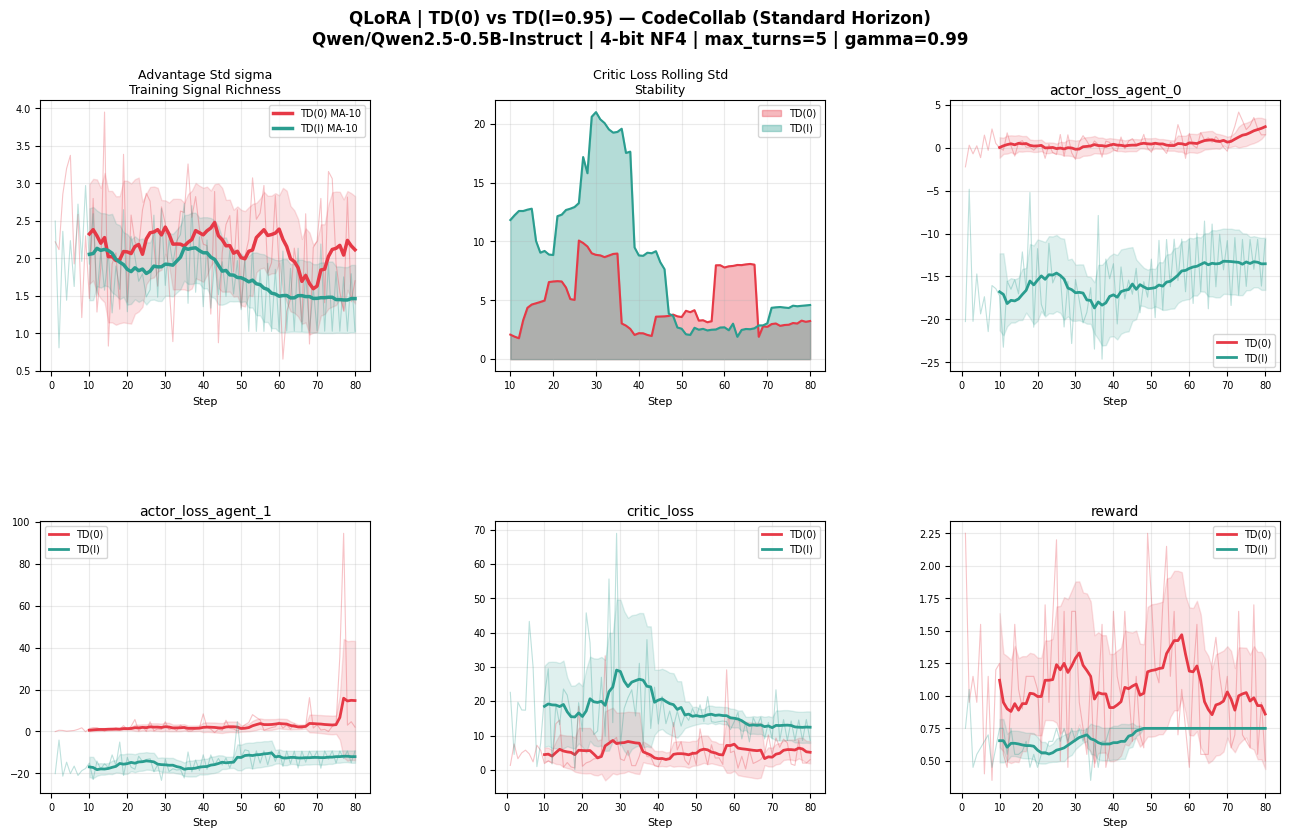

In [9]:
def moving_avg(x: list, w: int = 5) -> np.ndarray:
    arr = np.array(x, dtype=float)
    return arr if len(arr) < w else np.convolve(arr, np.ones(w) / w, mode="valid")


def rolling_std(x: list, w: int = 5) -> np.ndarray:
    arr = np.array(x, dtype=float)
    return np.array([arr[i : i + w].std() for i in range(len(arr) - w + 1)])


COLOR_TD0 = "#e63946"
COLOR_TDL = "#2a9d8f"
WINDOW = max(3, min(len(steps_log) // 8, 10))

all_keys = sorted(set(log_td0.keys()) | set(log_tdl.keys()))
n_panels = 2 + len(all_keys)
cols = 3
rows = (n_panels + cols - 1) // cols

fig = plt.figure(figsize=(16, 4.5 * rows))
fig.suptitle(
    f"QLoRA | TD(0) vs TD(l={CFG.td_lambda}) — CodeCollab (Standard Horizon)\n"
    f"{CFG.model_name} | 4-bit NF4 | max_turns={CFG.max_turns} | gamma={CFG.gamma}",
    fontsize=12,
    fontweight="bold",
)
gs = gridspec.GridSpec(rows, cols, figure=fig, hspace=0.55, wspace=0.38)

ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(steps_log, adv_std_td0, color=COLOR_TD0, lw=0.8, alpha=0.3)
ax0.plot(steps_log, adv_std_tdl, color=COLOR_TDL, lw=0.8, alpha=0.3)
if len(adv_std_td0) >= WINDOW:
    ma0 = moving_avg(adv_std_td0, WINDOW)
    mal = moving_avg(adv_std_tdl, WINDOW)
    std0 = rolling_std(adv_std_td0, WINDOW)
    stdl = rolling_std(adv_std_tdl, WINDOW)
    ax0.plot(steps_log[WINDOW - 1 :], ma0, color=COLOR_TD0, lw=2.5, label=f"TD(0) MA-{WINDOW}")
    ax0.fill_between(
        steps_log[WINDOW - 1 :], ma0 - std0, ma0 + std0, color=COLOR_TD0, alpha=0.15
    )
    ax0.plot(steps_log[WINDOW - 1 :], mal, color=COLOR_TDL, lw=2.5, label=f"TD(l) MA-{WINDOW}")
    ax0.fill_between(
        steps_log[WINDOW - 1 :], mal - stdl, mal + stdl, color=COLOR_TDL, alpha=0.15
    )
ax0.set_title("Advantage Std sigma\nTraining Signal Richness", fontsize=9, pad=4)
ax0.set_xlabel("Step", fontsize=8)
ax0.legend(fontsize=7)
ax0.grid(True, alpha=0.25)
ax0.tick_params(labelsize=7)

ax1 = fig.add_subplot(gs[0, 1])
if "critic_loss" in log_td0 and len(log_td0["critic_loss"]) >= WINDOW:
    var0 = rolling_std(log_td0["critic_loss"], WINDOW)
    varl = rolling_std(log_tdl.get("critic_loss", [0.0] * len(steps_log)), WINDOW)
    xs_v = steps_log[WINDOW - 1 :]
    ax1.fill_between(xs_v[: len(var0)], 0, var0, color=COLOR_TD0, alpha=0.35, label="TD(0)")
    ax1.fill_between(xs_v[: len(varl)], 0, varl, color=COLOR_TDL, alpha=0.35, label="TD(l)")
    ax1.plot(xs_v[: len(var0)], var0, color=COLOR_TD0, lw=1.5)
    ax1.plot(xs_v[: len(varl)], varl, color=COLOR_TDL, lw=1.5)
ax1.set_title("Critic Loss Rolling Std\nStability", fontsize=9, pad=4)
ax1.set_xlabel("Step", fontsize=8)
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.25)
ax1.tick_params(labelsize=7)

for idx, key in enumerate(all_keys):
    pos = idx + 2
    ax = fig.add_subplot(gs[pos // cols, pos % cols])
    for vals, color, label in [
        (log_td0.get(key, []), COLOR_TD0, "TD(0)"),
        (log_tdl.get(key, []), COLOR_TDL, "TD(l)"),
    ]:
        if not vals:
            continue
        xs_cut = steps_log[-len(vals) :]
        ax.plot(xs_cut, vals, color=color, lw=0.8, alpha=0.3)
        if len(vals) >= WINDOW:
            ma_vals = moving_avg(vals, WINDOW)
            std_vals = rolling_std(vals, WINDOW)
            ax.plot(xs_cut[WINDOW - 1 :], ma_vals, color=color, lw=2, label=label)
            ax.fill_between(
                xs_cut[WINDOW - 1 :],
                ma_vals - std_vals,
                ma_vals + std_vals,
                color=color,
                alpha=0.15,
            )
    ax.set_title(key, fontsize=10, pad=4)
    ax.set_xlabel("Step", fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.25)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig("standard_horizon.png", dpi=150, bbox_inches="tight")
plt.show()
